In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
data = pd.read_csv("../data/marketing_campaign.csv")
data.head()

,campaign_id,channel,impressions,clicks,conversions,cost,segment
0,1,Facebook,10000,800,120,500,Youth
1,2,Google Ads,15000,1200,200,900,Working Professionals
2,3,Instagram,12000,950,150,600,Youth
3,4,Email,8000,500,100,200,Students
4,5,LinkedIn,9000,400,80,700,Professionals


In [53]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   campaign_id  10 non-null     int64
 1   channel      10 non-null     str  
 2   impressions  10 non-null     int64
 3   clicks       10 non-null     int64
 4   conversions  10 non-null     int64
 5   cost         10 non-null     int64
 6   segment      10 non-null     str  
dtypes: int64(5), str(2)
memory usage: 692.0 bytes


In [54]:
data.describe()

,campaign_id,impressions,clicks,conversions,cost
count,10.00000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,11120.000000,797.000000,135.000000,592.000000
std,3.02765,2740.559554,321.767687,44.534631,248.363533
min,1.00000,8000.000000,400.000000,80.000000,200.000000
25%,3.25000,9050.000000,512.500000,102.500000,505.000000
50%,5.50000,10500.000000,825.000000,125.000000,610.000000
75%,7.75000,12375.000000,987.500000,157.500000,707.500000
max,10.00000,16000.000000,1300.000000,210.000000,950.000000


In [55]:
data["CTR"] = data["clicks"] / data["impressions"]
data["conversion_rate"] = data["conversions"] / data["clicks"]
data["cost_per_conversion"] = data["cost"] / data["conversions"]

data.head()

,campaign_id,channel,impressions,clicks,conversions,cost,segment,CTR,conversion_rate,cost_per_conversion
0,1,Facebook,10000,800,120,500,Youth,0.080000,0.150000,4.166667
1,2,Google Ads,15000,1200,200,900,Working Professionals,0.080000,0.166667,4.500000
2,3,Instagram,12000,950,150,600,Youth,0.079167,0.157895,4.000000
3,4,Email,8000,500,100,200,Students,0.062500,0.200000,2.000000
4,5,LinkedIn,9000,400,80,700,Professionals,0.044444,0.200000,8.750000


In [56]:
data.groupby("channel")[["clicks","conversions","cost"]].sum()

,clicks,conversions,cost
channel,,,
Email,1050,210,420
Facebook,1650,250,1020
Google Ads,2500,410,1850
Instagram,1950,310,1220
LinkedIn,820,170,1410


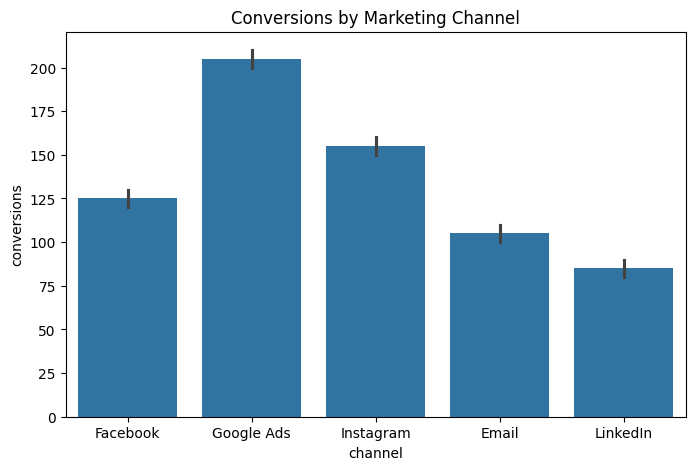

In [57]:
plt.figure(figsize=(8,5))
sns.barplot(x="channel", y="conversions", data=data)

plt.title("Conversions by Marketing Channel")
plt.savefig("../visuals/conversions_by_channel.png")
plt.show()

In [58]:
data.isnull().sum()

campaign_id            0
channel                0
impressions            0
clicks                 0
conversions            0
cost                   0
segment                0
CTR                    0
conversion_rate        0
cost_per_conversion    0
dtype: int64

In [59]:
data["channel"].unique()

<StringArray>
['Facebook', 'Google Ads', 'Instagram', 'Email', 'LinkedIn']
Length: 5, dtype: str

In [60]:
data["segment"].unique()

<StringArray>
['Youth', 'Working Professionals', 'Students', 'Professionals']
Length: 4, dtype: str

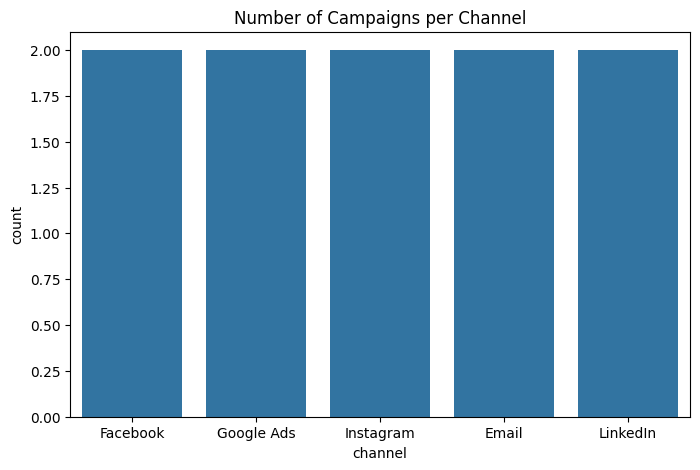

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x="channel", data=data)

plt.title("Number of Campaigns per Channel")
plt.savefig("../visuals/campaign_distribution.png")
plt.show()

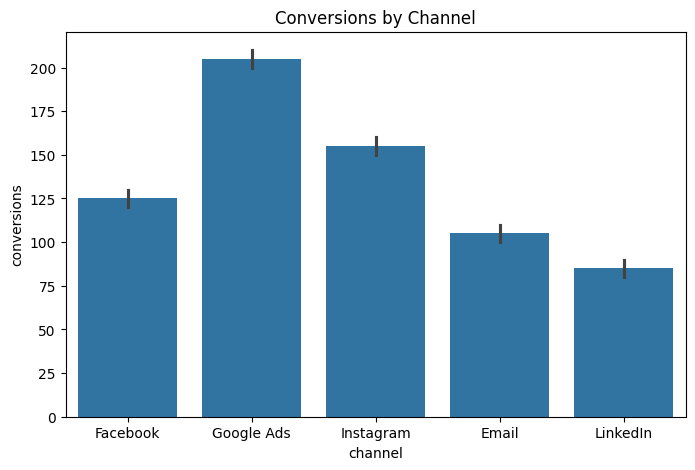

In [62]:
plt.figure(figsize=(8,5))
sns.barplot(x="channel", y="conversions", data=data)

plt.title("Conversions by Channel")
plt.savefig("../visuals/conversions_by_channel.png")
plt.show()

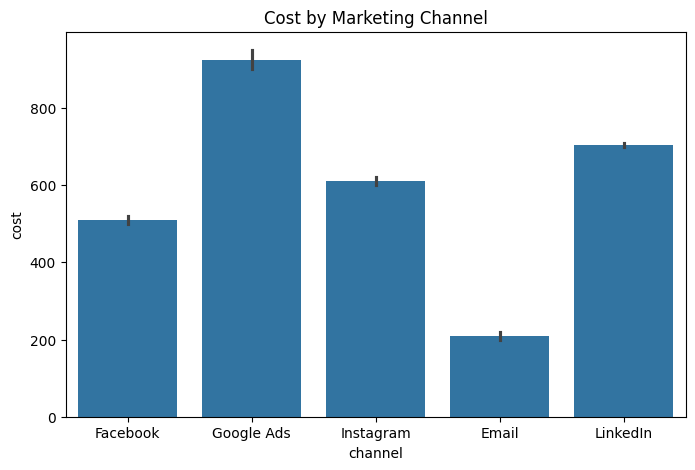

In [63]:
plt.figure(figsize=(8,5))
sns.barplot(x="channel", y="cost", data=data)

plt.title("Cost by Marketing Channel")
plt.savefig("../visuals/cost_by_channel.png")
plt.show()

In [64]:
segment_analysis = data.groupby("segment")[["conversions","cost"]].sum()
segment_analysis

,conversions,cost
segment,,
Professionals,380,2360
Students,260,820
Working Professionals,310,1120
Youth,400,1620


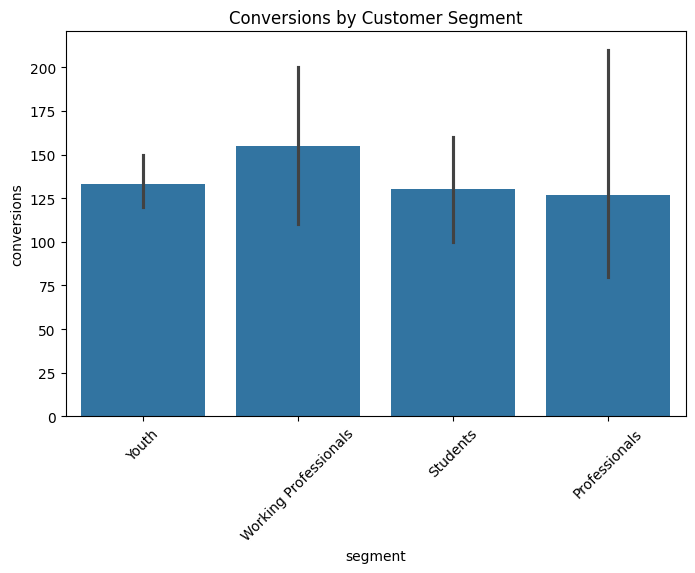

In [65]:
plt.figure(figsize=(8,5))
sns.barplot(x="segment", y="conversions", data=data)

plt.title("Conversions by Customer Segment")
plt.xticks(rotation=45)
plt.savefig("../visuals/conversions_by_segment.png")
plt.show()

## Key Insights

1. Google Ads generates the highest conversions.
2. Email campaigns have the lowest marketing cost.
3. Youth and Professionals segments respond strongly to campaigns.
4. LinkedIn campaigns cost more but target professional audiences.

In [66]:
from pandasql import sqldf

In [67]:
query = """
SELECT channel, SUM(conversions) AS total_conversions
FROM data
GROUP BY channel
ORDER BY total_conversions DESC
"""

result = sqldf(query)
result

,channel,total_conversions
0,Google Ads,410
1,Instagram,310
2,Facebook,250
3,Email,210
4,LinkedIn,170


In [68]:
query = """
SELECT channel,
SUM(cost) AS total_cost,
SUM(conversions) AS conversions,
SUM(cost)/SUM(conversions) AS cost_per_conversion
FROM data
GROUP BY channel
ORDER BY cost_per_conversion
"""

cost_analysis = sqldf(query)
cost_analysis

,channel,total_cost,conversions,cost_per_conversion
0,Email,420,210,2
1,Instagram,1220,310,3
2,Facebook,1020,250,4
3,Google Ads,1850,410,4
4,LinkedIn,1410,170,8


In [69]:
query = """
SELECT segment,
SUM(conversions) AS total_conversions
FROM data
GROUP BY segment
ORDER BY total_conversions DESC
"""

segment_performance = sqldf(query)
segment_performance

,segment,total_conversions
0,Youth,400
1,Professionals,380
2,Working Professionals,310
3,Students,260


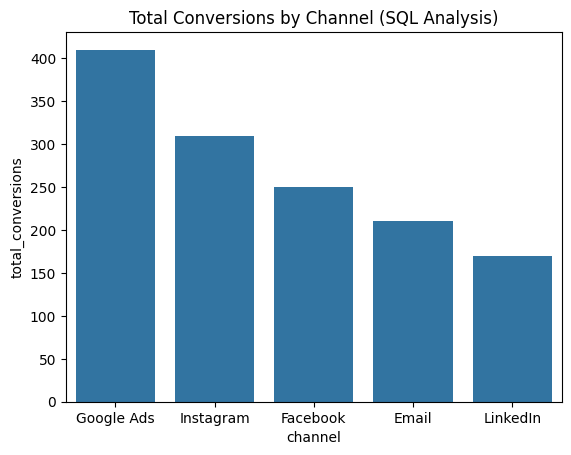

In [70]:
sns.barplot(x="channel", y="total_conversions", data=result)
plt.title("Total Conversions by Channel (SQL Analysis)")
plt.savefig("../visuals/sql_channel_conversions.png")
plt.show()

## SQL Analysis Insights

1. Google Ads generated the highest number of conversions.
2. Email campaigns show the lowest cost per conversion.
3. Professional segments respond well to LinkedIn campaigns.
4. Instagram performs strongly among youth audiences.